# Finding a balance between cherry and vanilla tables
This is for 1.125P(Vanilla) - P(Cherry) > 0

## Imports

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
from functions import *
from scipy.optimize import minimize, Bounds

## Load data
Data format:
    - results: [K_js, m_0, final_cost, m_values] for each alpha
    - vanilla : [v_cost, m_values] for each alpha
    
alpha's used:
    [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

In [3]:
with open('1.125_results.pkl', 'rb') as f:
    results = pickle.load(f)
    
with open('1.125_vanilla.pkl', 'rb') as f:
    vanilla_results = pickle.load(f)

In [4]:
# global variables for plots
alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
N = 2 ** 20
p = 1-e**-2 # our table coverage

## Plot m0 for each alpha for vanilla and cherry tables

In [5]:
def plot_mjs(results, vanilla_results):

    # for each alpha (so each bit in each result
    for i in range(len(results)):
        m_values = results[i][3]
        vanilla_m_values = vanilla_results[i][1]
        alpha = alphas[i]

        fig = plt.figure()
        ax = fig.add_subplot(1,1,1)
        
        ax.plot(m_values, c= '#721011', label = "cherry")
        ax.plot(vanilla_m_values, c = '#fbde98', label = "vanilla")
        ax.set_ylabel(r"$m_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
        ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
        # legend
        plt.legend()
        
        fig.suptitle(f"Number of unique elements per column where $m_0$ = {m_values[0]} ($α$ = {alpha}), N = {N}, t = {len(m_values)}")
        # plt.savefig(f"plots/cherry_w_vanilla/m_curve_alpha_{alpha}_N_{N}.png")

In [6]:
def plot_vanilla_mjs(vanilla_results):
    
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    for i in range(len(vanilla_results)):
        m_values = vanilla_results[i][1]
        alpha = alphas[i]
        
        ax.plot(m_values, label = "alpha = "+str(alpha))
        
    ax.set_ylabel(r"$m_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    # legend
    plt.legend()
    
    fig.suptitle(f"Number of unique elements per column for vanilla tables")
    plt.savefig("m_curve_vanilla.png")
    
    

In [7]:
# plot the # of endpoints for each alpha for vanilla tables
def plot_vanilla_endpoints(results):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    points = []
    
    for i in range(len(results)):
        points.append(results[i][1][-1])
        
    ax.plot(alphas, points)
    plt.xticks(alphas)
    ax.set_ylabel(r"$m_{t}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("alpha", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    fig.suptitle(f"Number of Endpoints for each Alpha for Vanilla Tables")
        

In [8]:
# plot the # of endpoints for each alpha for cherry tables
def plot_cherry_endpoints(results):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    points = []
    
    for i in range(len(results)):
        points.append(results[i][3][-1])
        
    ax.plot(alphas, points)
    plt.xticks(alphas)
    ax.set_ylabel(r"$m_{t}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("alpha", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    fig.suptitle(f"Number of Endpoints for each Alpha for Cherry Tables")

In [9]:
# plot all endpoints for each alpha for cherry and vanilla tables
def plot_all_endpoints(results, vanilla_results):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    cherry_points = []
    vanilla_points = []
    
    for i in range(len(results)):
        cherry_points.append(results[i][3][-1])
        vanilla_points.append(vanilla_results[i][1][-1])
        
    ax.plot(alphas, vanilla_points, label = "vanilla")
    ax.plot(alphas, cherry_points, label = "cherry")
    
    plt.xticks(alphas)
    ax.set_ylabel(r"$m_{t}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("alpha", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    plt.legend()
    fig.suptitle(f"Number of Endpoints for each Alpha for Cherry and Vanilla Tables")
    plt.savefig("endpoints.png")

In [10]:
# plot the number of points in each column for each alpha
# so end up with 8 graphs
# plot_mjs(results, vanilla_results)

In [11]:
# plot_vanilla_mjs(vanilla_results)

In [12]:
# plot_vanilla_endpoints(vanilla_results)
# plot_cherry_endpoints(results)
# plot_all_endpoints(results, vanilla_results)    # number of endpoints for vanilla v cherry

## Greedy method
* For an alpha, choose (out of vanilla and cherry) the table with the maximum number of points in the next colum
*   but then it'll always choose vanilla at the start until cherry has more points in the next column
* we can look at the plots to see when cherry takes over, and then choose cherry
* we should also look at the cost of doing each step and create a cumulative sum

In [13]:
## TODO: plot new k curve, plot m_0 points for 3 tables on same graph

def plot_kjs(K_js, alpha):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.plot(K_js, "k", label="K")
    ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12, "labelpad": -2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12})

    fig.suptitle(f"K curve for Hybrid Table where $α$ = {alpha}")
    plt.savefig("hybrid/K_curve_method_1.png")

In [14]:
# adjusted optimise function to take in m_0 and t 
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, m_0, t):   # add v_cost if want vanilla cost to be set beforehand
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    bound = Bounds([1 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * 1.125
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    # P(vanilla) - P(cherry) > 0 the same precomputation cost
    # but want the vanilla cost to be set beforehand
    # ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps":0.5})
    
    ## res.x is the result of the optimization
    print(m_0)
    print(t)
    print(len(res.x))
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    print(f"Final cost: {final_cost}")
    print(f"Final m_t: {m_values[-1]}")
    return res.x, m_0, final_cost, m_values

In [15]:
# greedy method
# given an alpha
def greedy_method(results, vanilla_results, alpha):
    
    t = len(results[0][0]) # number of columns
    alpha_index = alphas.index(alpha)   # index of alpha in the results
    
    cherry_kj = [-1 for i in range(t)] # -1 to indicate that we haven't chosen cherry yet
    m_values = []   # to store the number of points in each column
    
    cost = 0    # to store the cost of the table
    
    # choose the largest m_0 between cherry and vanilla tables - is this the best approach?
    m = max(results[alpha_index][1], vanilla_results[alpha_index][1][0])  
    print(m)
    # store the m_0 value to return
    m_0 = m
    
    # for the number of columns
    for i in range(t):
        # store the current m value in the array
        m_values.append(m)
        
        # calculate the number of points using the cherry table would give for the next column
        kj, c_m0, cherry_cost, cherry_m = optimise_kj(N, m, 2)
        
        # calculate the number of points using the vanilla table would give for the next column
        v_cost, v_m = vanilla_cost(N, m, 2)
        
        # choose which is the best table to use
        print(cherry_m)
        if cherry_m[1] > v_m[1]:
            print("kj = ", kj)
            cherry_kj[i] = kj[1]    
            m = cherry_m[1]
            cost += cherry_cost
        else:
            m = v_m[1]
            cost += v_cost
            
    return cost, m_0, cherry_kj, m_values
    

In [16]:
# see if greedy method works
# with alpha = 0.95
res = greedy_method(results, vanilla_results, 0.95)

206425
Optimization terminated successfully    (Exit mode 0)
            Current function value: -187753.7847188728
            Iterations: 12
            Function evaluations: 38
            Gradient evaluations: 12
206425
2
2
Final cost: 443026.84961124626
Final m_t: 187753.7847188728
[206425, 187753.7847188728]
kj =  [  1.         661.85477553]
Optimization terminated successfully    (Exit mode 0)
            Current function value: -172252.93360173877
            Iterations: 12
            Function evaluations: 38
            Gradient evaluations: 12
187753.7847188728
2
2
Final cost: 404615.6346665994
Final m_t: 172252.93360173877
[187753.7847188728, 172252.93360173877]
kj =  [  1.         666.96235616]
Optimization terminated successfully    (Exit mode 0)
            Current function value: -159172.40988287554
            Iterations: 12
            Function evaluations: 38
            Gradient evaluations: 12
172252.93360173877
2
2
Final cost: 372489.2938573569
Final m_t: 159172.4

In [17]:
res

(15210352.143223295,
 206425,
 [661.8547755335741,
  666.9623561587134,
  671.2482710647837,
  674.8975216585136,
  678.0431561186479,
  680.7833817926684,
  683.1923111699133,
  685.3269501690093,
  687.2318809062225,
  688.9424820425254,
  690.4871943241624,
  691.889146689872,
  693.167344465824,
  694.3375515762609,
  695.4129550798245,
  696.4046723179362,
  697.3221426034006,
  698.1734330260279,
  698.9654796125884,
  699.7042792661813,
  700.3950438336674,
  701.0423247580417,
  701.6501146694106,
  702.2219307612507,
  702.7608836294457,
  703.2697344945551,
  703.7509429927079,
  704.2067073267622,
  704.6389981555017,
  705.0495873508324,
  705.4400724736453,
  705.8118977311917,
  706.1663719810276,
  706.5046842409569,
  706.8279171182445,
  707.1370584684046,
  707.4330115607972,
  707.7166039491544,
  707.9885952440627,
  708.2496839784039,
  708.5005136087902,
  708.7416778529282,
  708.973725415204,
  709.197164181656,
  709.4124649406924,
  709.6200647132666,
  709.82

In [18]:
# vanilla table cost
print(vanilla_results[-1][0])
# cherry table cost
print(results[-1][2])
# new table cost
print(res[0])

6417206.57200695
7219304.581003026
15210352.143223295


In [19]:
# vanilla table endpoints
print(vanilla_results[-1][1][-1])
# cherry table endpoints
print(results[-1][3][-1])
# new table endpoints
print(res[3][-1])

9837.999906975776
11791.967667513165
12306.484610806627


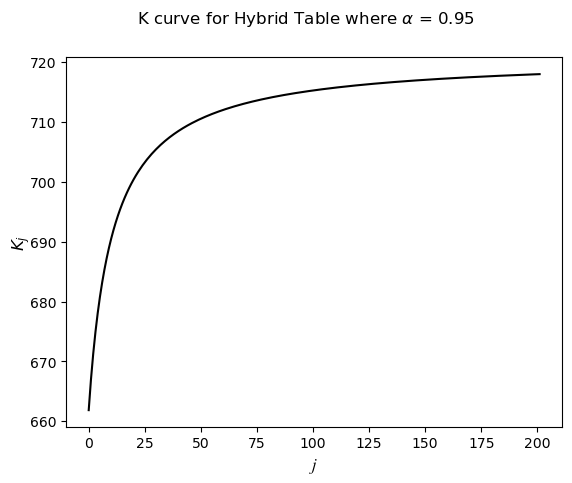

In [20]:
plot_kjs(res[2], 0.95)